In [18]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.widgets import Slider, RadioButtons, TextBox


In [20]:
def load_pareto_history(filepath="pareto_history.pkl"):
    """
    Carga el archivo pickle que contiene fronts_history.
    Devuelve un dict: {generacion: {nivel_frente: [registros...]}}
    """
    with open(filepath, "rb") as f:
        history = pickle.load(f)
    return history

In [21]:
def pareto_history_to_df_for_gen(filepath="pareto_history.pkl", generation=0):
    """
    Converts Pareto fronts history for a given generation into a DataFrame
    with columns: generation, front_level, accuracy, params, inference_time.
    """
    history = load_pareto_history(filepath)
    if generation not in history:
        raise ValueError(f"Generation {generation} not found in history.")
    
    records = []
    for level, recs in history[generation].items():
        for rec in recs:
            records.append({
                "generation": generation,
                "front_level": level,
                "accuracy": rec["accuracy"],
                "params": rec["params"],
                "inference_time": rec["inference_time"]
            })
    df = pd.DataFrame(records)
    return df

In [26]:
def visualize_generation(filepath="pareto_history.pkl", generation=0,
                        dims="3d", x_axis="params", y_axis="inference_time", z_axis="accuracy"):
    """
    Visualizes Pareto fronts for a given generation in either 2D or 3D.
    
    dims: "2d" or "3d"
    For 2D, use x_axis and y_axis. For 3D, use x_axis, y_axis, z_axis.
    """
    df = pareto_history_to_df_for_gen(filepath, generation)
    
    if dims == "3d":
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(df[x_axis], df[y_axis], df[z_axis],
                            c=df["front_level"], cmap='viridis')
        ax.set_xlabel(x_axis.capitalize().replace('_', ' '))
        ax.set_ylabel(y_axis.capitalize().replace('_', ' '))
        ax.set_zlabel(z_axis.capitalize().replace('_', ' '))
        ax.set_title(f"Pareto Fronts Levels - Generation {generation} (3D)")
        cbar = plt.colorbar(scatter, pad=0.1)
        cbar.set_label("Front Level")
        ax.grid(True)
        plt.show()
        
    elif dims == "2d":
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111)
        scatter = ax.scatter(df[x_axis], df[y_axis],
                            c=df["front_level"], cmap='viridis')
        ax.set_xlabel(x_axis.capitalize().replace('_', ' '))
        ax.set_ylabel(y_axis.capitalize().replace('_', ' '))
        ax.set_title(f"Pareto Fronts Levels - Generation {generation} (2D)")
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label("Front Level")
        ax.grid(True)
        plt.show()
        
    else:
        raise ValueError("dims must be '2d' or '3d'")



In [ ]:
history = load_pareto_history("experiment_cifar10_nsga/exp1_repeat_1/pareto_history.pkl")


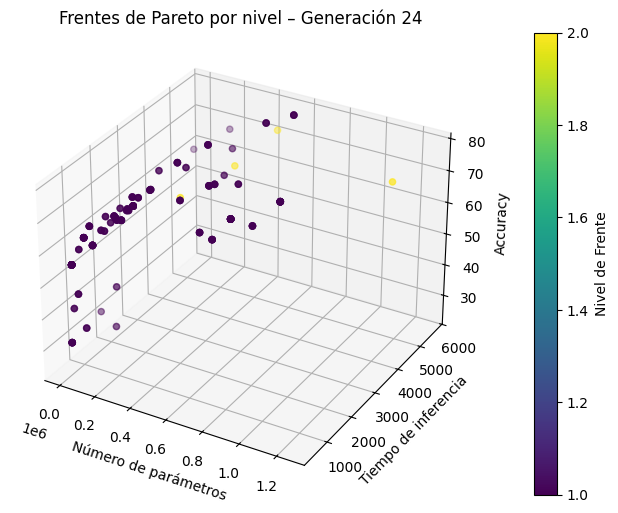

In [17]:
visualize_generation("experiment_cifar10_nsga/exp1_repeat_1/pareto_history.pkl", generation=24)

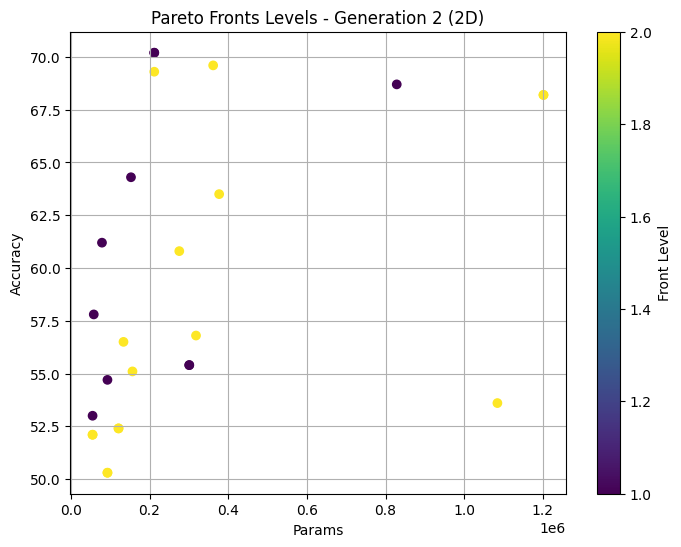

In [29]:
visualize_generation("experiment_cifar10_nsga/exp1_repeat_1/pareto_history.pkl", generation=2, dims="2d", x_axis="params", y_axis="accuracy")

In [33]:
import ipywidgets as widgets
from IPython.display import display, clear_output